# Explore here

Diabetes prediction

In [17]:
train_data = pd.read_csv("../data/processed/clean_train.csv")
test_data = pd.read_csv("../data/processed/clean_test.csv")


In [18]:
# Split features and target
X_train = train_data.drop("Outcome", axis=1)
y_train = train_data["Outcome"]

X_test = test_data.drop("Outcome", axis=1)
y_test = test_data["Outcome"]


In [26]:
train_data.describe()


,Pregnancies,Glucose,BloodPressure,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,3.742671,120.855049,69.415309,81.438111,31.983388,0.469168,32.907166,0.346906
std,3.313264,32.035057,18.512599,116.234835,7.740625,0.336847,11.503437,0.476373
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,27.100000,0.241500,24.000000,0.000000
50%,3.000000,117.000000,72.000000,42.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,139.000000,80.000000,129.750000,36.375000,0.613750,40.000000,1.000000
max,17.000000,199.000000,122.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [27]:
train_data.isnull().sum()


Pregnancies                 0
Glucose                     0
BloodPressure               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

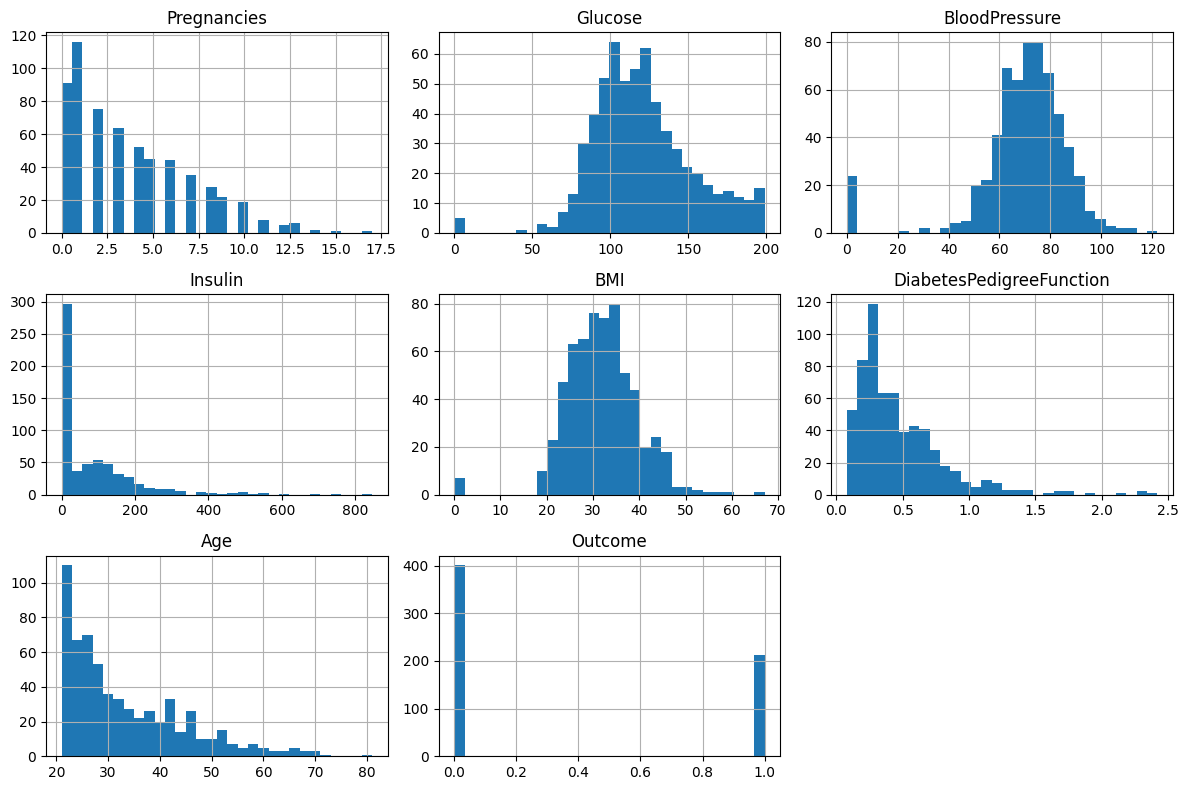

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

train_data.hist(bins=30, figsize=(12, 8))
plt.tight_layout()
plt.show()


Random forest model

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create the model
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.80      0.82      0.81        99
           1       0.66      0.64      0.65        55

    accuracy                           0.75       154
   macro avg       0.73      0.73      0.73       154
weighted avg       0.75      0.75      0.75       154



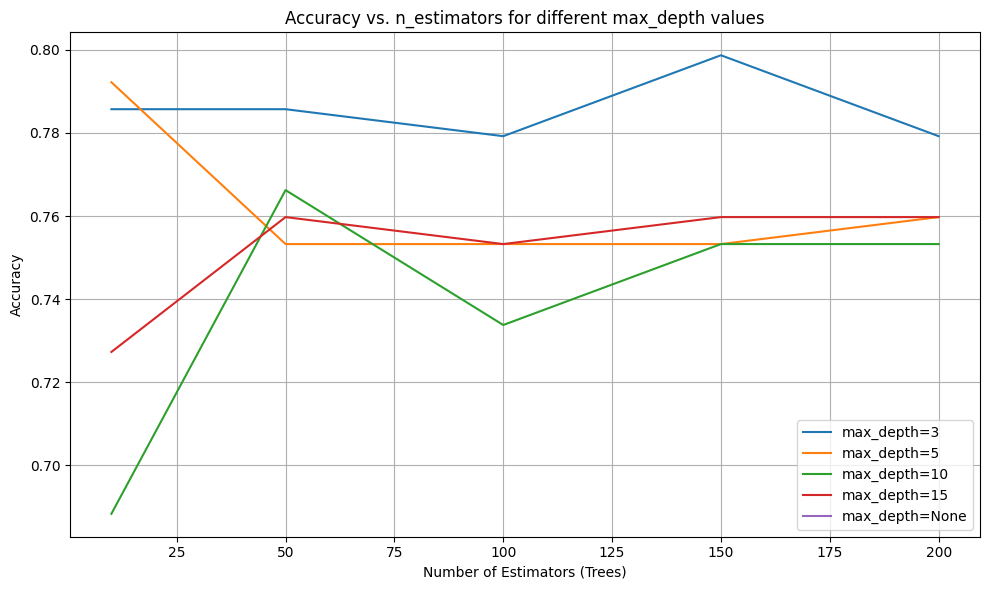

In [20]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Lists of values to try
n_estimators_list = [10, 50, 100, 150, 200]
max_depth_list = [3, 5, 10, 15, None]

# Store results
results = []

for n in n_estimators_list:
    for depth in max_depth_list:
        model = RandomForestClassifier(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        results.append((n, depth, acc))

# Convert to DataFrame for easy plotting
import pandas as pd
results_df = pd.DataFrame(results, columns=["n_estimators", "max_depth", "accuracy"])

# Plot
plt.figure(figsize=(10, 6))
for depth in max_depth_list:
    subset = results_df[results_df["max_depth"] == depth]
    plt.plot(subset["n_estimators"], subset["accuracy"], label=f"max_depth={depth}")
    
plt.title("Accuracy vs. n_estimators for different max_depth values")
plt.xlabel("Number of Estimators (Trees)")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


"Accuracy improves up to 100 estimators, then levels off — I’ll stick with 100."

"max_depth=10 gives the best and most stable results across all values."

"max_depth=None slightly overfits — it performs great on training but worse on testing."



In [21]:
n_estimators_list = [10, 25, 50, 75, 100, 125, 150, 175, 200]
max_depth_list = [3, 5, 7, 10, 12, 15, None]


In [22]:
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
print("Cross-validated accuracy:", scores.mean())


Cross-validated accuracy: 0.7785152605624417


In [23]:
import joblib

# Re-train on the full training set if needed
final_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
final_model.fit(X_train, y_train)

# Save it
joblib.dump(final_model, "../models/random_forest_model.pkl")


['../models/random_forest_model.pkl']

In [24]:
y_pred = final_model.predict(X_test)
print("Final accuracy on test set:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Final accuracy on test set: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        99
           1       0.62      0.65      0.64        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.74       154



“Using cross-validation, we found that a Random Forest with 100 trees and a max depth of 10 gave the most stable and accurate results, achieving ~78% average accuracy across folds.”

